## Crypto Streaming Data Pipeline
1 CoinGecko API
      
2 api_ingestion.py
      
3 data/input_data/
      
4 PySpark Structured Streaming
      
5 data/output_data/

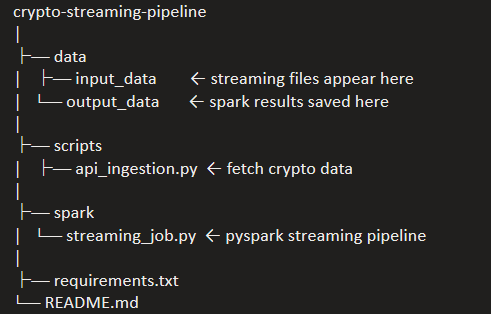

Delete old directories (clean start)

In [15]:
import shutil
import os

base_path = "/content/crypto-streaming-pipeline"

if os.path.exists(base_path):
    shutil.rmtree(base_path)
    print("Old project directory deleted")

os.makedirs(base_path, exist_ok=True)

Old project directory deleted


2Create folder *structure*

In [16]:
import os

BASE_PATH = "/content/crypto-streaming-pipeline"

folders = [
    f"{BASE_PATH}/data/input_data",
    f"{BASE_PATH}/data/output_data",
    f"{BASE_PATH}/scripts",
    f"{BASE_PATH}/spark"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure ready")

Project structure ready


3️Install dependencies

In [17]:
!pip install pyspark requests pandas

Step 3 — Master Notebook Runs Everything

In [26]:
!python /content/crypto-streaming-pipeline/scripts/api_ingestion_bitcoin.py

Created: /content/crypto-streaming-pipeline/data/input_data/crypto_1776398187.csv
Created: /content/crypto-streaming-pipeline/data/input_data/crypto_1776398192.csv
Created: /content/crypto-streaming-pipeline/data/input_data/crypto_1776398197.csv
Created: /content/crypto-streaming-pipeline/data/input_data/crypto_1776398202.csv
Created: /content/crypto-streaming-pipeline/data/input_data/crypto_1776398207.csv


In [27]:
!python /content/crypto-streaming-pipeline/scripts/api_ingestion_INR.py

Live USD → INR: 93.245552


In [28]:
!python /content/crypto-streaming-pipeline/spark/streaming_job.py

Using INR rate: 93.245552
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/17 03:56:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/17 03:56:57 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/17 03:57:03 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/04/17 03:57:08 WARN HDFSBackedStateStoreProvider: The state for version 5 doesn't exist in loadedMaps. Reading snapshot file and delta files if needed...Note that this is normal for the first batch of starting query.
26/04/17 03:57:08 WARN HDFSBackedStateStoreProvider: The state for version 5 doesn't exist in loadedMaps. Reading snapshot file and delta files if needed...N

In [30]:
# !zip -r crypto-streaming-pipeline.zip /content/crypto-streaming-pipeline
# from google.colab import files
# files.download("crypto-streaming-pipeline.zip")

  adding: content/crypto-streaming-pipeline/ (stored 0%)
  adding: content/crypto-streaming-pipeline/spark/ (stored 0%)
  adding: content/crypto-streaming-pipeline/spark/streaming_job.py (deflated 63%)
  adding: content/crypto-streaming-pipeline/data/ (stored 0%)
  adding: content/crypto-streaming-pipeline/data/inr_rate.json (stored 0%)
  adding: content/crypto-streaming-pipeline/data/input_data/ (stored 0%)
  adding: content/crypto-streaming-pipeline/data/input_data/crypto_1776398187.csv (deflated 25%)
  adding: content/crypto-streaming-pipeline/data/input_data/crypto_1776397945.csv (stored 0%)
  adding: content/crypto-streaming-pipeline/data/input_data/crypto_1776397930.csv (deflated 25%)
  adding: content/crypto-streaming-pipeline/data/input_data/crypto_1776397935.csv (deflated 25%)
  adding: content/crypto-streaming-pipeline/data/input_data/crypto_1776397940.csv (deflated 25%)
  adding: content/crypto-streaming-pipeline/data/input_data/crypto_1776398207.csv (stored 0%)
  adding: co

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CryptoStreaming") \
    .getOrCreate()

df = spark.read.parquet(
    "/content/crypto-streaming-pipeline/data/output_data",
    header=True,
    inferSchema=True
)

df.show()

+--------------------+--------+-----------------+------------+
|              window|   asset|    avg_price_inr|anomaly_flag|
+--------------------+--------+-----------------+------------+
|{2026-04-17 03:52...|ethereum|   217112.9432768|       SPIKE|
|{2026-04-17 03:52...| bitcoin|6969452.293136001|       SPIKE|
+--------------------+--------+-----------------+------------+

